# Notebook 8 — De-biased Adaptive Financial Transformer

This notebook extends the Feature-Guided Transformer by introducing adaptive attention mechanisms specifically designed for financial time series.

Key contributions:

- Market regime encoder
- Dynamic feature-group gating
- Adaptive financial attention
- Relative temporal bias
- Learned residual scaling
- CLS token aggregation
- Mixed precision training
- AdamW optimization

In [1]:
import math
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset,DataLoader

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from pipeline.metrics import evaluate_trading_metrics

## Load Dataset

Load the processed train, validation and test tensors together with the engineered feature metadata.

In [2]:
# Load the master dataset and perform scaling & sequence alignment
df = pd.read_parquet("processed_data/master_dataset.parquet")

target_col = "Future_Return"
ignore = ["Date", "Future_Close", "Future_Return", "Target_Direction"]
feature_cols = [c for c in df.columns if c not in ignore]

X = df[feature_cols]
y = df[target_col]

n = len(df)
train_ratio = 0.7
val_ratio = 0.15

train_end = int(n * train_ratio)
val_end = int(n * (train_ratio + val_ratio))

X_train_raw = X.iloc[:train_end]
X_val_raw = X.iloc[train_end:val_end]
X_test_raw = X.iloc[val_end:]

y_train_raw = y.iloc[:train_end]
y_val_raw = y.iloc[train_end:val_end]
y_test_raw = y.iloc[val_end:]

# Standard scaling (fit on training data only)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Corrected sequence generation (Fixed 1-day target alignment)
def create_sequences_fixed(X_scaled, y_series, seq_len=60):
    X_seq = []
    y_seq = []
    # Pair features ending at t-1 (X_scaled[i:i+seq_len]) with return starting at t-1 (y_series.iloc[i+seq_len-1])
    for i in range(len(X_scaled) - seq_len):
        X_seq.append(X_scaled[i : i + seq_len])
        y_seq.append(y_series.iloc[i + seq_len - 1])
    return np.array(X_seq), np.array(y_seq)

seq_length = 60
X_train_seq, y_train_seq = create_sequences_fixed(X_train_scaled, y_train_raw, seq_length)
X_val_seq, y_val_seq = create_sequences_fixed(X_val_scaled, y_val_raw, seq_length)
X_test_seq, y_test_seq = create_sequences_fixed(X_test_scaled, y_test_raw, seq_length)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train_seq, dtype=torch.float32)
y_train = torch.tensor(y_train_seq, dtype=torch.float32)
X_val = torch.tensor(X_val_seq, dtype=torch.float32)
y_val = torch.tensor(y_val_seq, dtype=torch.float32)
X_test = torch.tensor(X_test_seq, dtype=torch.float32)
y_test = torch.tensor(y_test_seq, dtype=torch.float32)

print("Scaled & Aligned Data Summary:")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Scaled & Aligned Data Summary:
Train: torch.Size([1844, 60, 95]) | Val: torch.Size([348, 60, 95]) | Test: torch.Size([349, 60, 95])


In [3]:
with open("pipeline/feature_columns.pkl","rb") as f:
    feature_columns=pickle.load(f)
print(", ".join(f"'{col}'" for col in feature_columns))

'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'Rolling_Volatility', 'Return', 'Log_Return', 'Price_Change', 'Previous_Close', 'Gap', 'High_Low_Range', 'Open_Close_Range', 'True_Range', 'Rolling_Mean', 'Rolling_STD', 'Rolling_Min', 'Rolling_Max', 'Rolling_Median', 'Rolling_Variance', 'Momentum_5', 'Momentum_10', 'Momentum_20', 'ROC_5', 'ROC_10', 'Volume_MA_5', 'Volume_MA_20', 'Relative_Volume', 'Volume_Change', 'Volume_Momentum', 'OBV', 'VWAP', 'Body', 'Upper_Wick', 'Lower_Wick', 'Full_Range', 'Body_Ratio', 'Upper_Wick_Ratio', 'Lower_Wick_Ratio', 'Body_to_Wick', 'ATR', 'Historical_Volatility', 'Parkinson_Volatility', 'Garman_Klass', 'EMA_9', 'EMA_21', 'EMA_50', 'EMA_200', 'MACD', 'EMA_12', 'EMA_26', 'Signal', 'MACD_Histogram', 'Rolling_Skew', 'Rolling_Kurtosis', 'Rolling_Zscore', 'Rolling_Max_Return', 'Rolling_Min_Return', 'Rolling_Return_STD', 'Day', 'Month', 'Quarter', 'DayOfWeek', 'WeekOfYear', 'Close_Lag_1', 'Return_Lag_1', 'Volume_Lag_1', 'Close_Lag_2', 'Return_Lag_2', 

## Feature Group Definition

The engineered features are organized into semantic groups.

Instead of learning attention over individual features, the model first learns the importance of each financial concept (price, momentum, volatility, trend, volume, etc.).

These group representations are later used by the adaptive attention mechanism.

In [4]:
FEATURE_GROUPS={
    "price":[
        "Close","High","Low","Open","Previous_Close",
        "Gap","Price_Change"
    ],

    "returns":[
        "Daily_Return","Return","Log_Return",
        "ROC_5","ROC_10"
    ],

    "volatility":[
        "Rolling_Volatility","ATR",
        "Historical_Volatility",
        "Parkinson_Volatility",
        "Garman_Klass",
        "Rolling_STD",
        "Rolling_Variance",
        "Rolling_Return_STD"
    ],

    "trend":[
        "EMA_9","EMA_21","EMA_50","EMA_200",
        "EMA_12","EMA_26",
        "MACD","Signal","MACD_Histogram"
    ],

    "momentum":[
        "Momentum_5","Momentum_10","Momentum_20"
    ],

    "volume":[
        "Volume",
        "Volume_MA_5",
        "Volume_MA_20",
        "Relative_Volume",
        "Volume_Change",
        "Volume_Momentum",
        "OBV",
        "VWAP"
    ],

    "candlestick":[
        "Body",
        "Upper_Wick",
        "Lower_Wick",
        "Full_Range",
        "Body_Ratio",
        "Upper_Wick_Ratio",
        "Lower_Wick_Ratio",
        "Body_to_Wick",
        "High_Low_Range",
        "Open_Close_Range",
        "True_Range"
    ],

    "statistics":[
        "Rolling_Mean",
        "Rolling_Min",
        "Rolling_Max",
        "Rolling_Median",
        "Rolling_Skew",
        "Rolling_Kurtosis",
        "Rolling_Zscore",
        "Rolling_Max_Return",
        "Rolling_Min_Return"
    ],

    "lags":[
        "Close_Lag_1","Return_Lag_1","Volume_Lag_1",
        "Close_Lag_2","Return_Lag_2","Volume_Lag_2",
        "Close_Lag_3","Return_Lag_3","Volume_Lag_3",
        "Close_Lag_5","Return_Lag_5","Volume_Lag_5",
        "Close_Lag_10","Return_Lag_10","Volume_Lag_10"
    ],

    "breakout":[
        "Rolling_High_5","Rolling_Low_5",
        "Rolling_High_10","Rolling_Low_10",
        "Rolling_High_20","Rolling_Low_20",
        "Distance_From_High_5",
        "Distance_From_Low_5",
        "Distance_From_High_10",
        "Distance_From_Low_10",
        "Distance_From_High_20",
        "Distance_From_Low_20",
        "Range_Position",
        "Breakout_20",
        "Breakdown_20"
    ],

    "calendar":[
        "Day",
        "Month",
        "Quarter",
        "DayOfWeek",
        "WeekOfYear"
    ]
}

In [5]:
FEATURE_INDICES={
    group:[feature_columns.index(f) for f in cols]
    for group,cols in FEATURE_GROUPS.items()
}

In [6]:
for group,idx in FEATURE_INDICES.items():
    print(f"{group:15s} {len(idx):2d} features")

price            7 features
returns          5 features
volatility       8 features
trend            9 features
momentum         3 features
volume           8 features
candlestick     11 features
statistics       9 features
lags            15 features
breakout        15 features
calendar         5 features


In [7]:
BATCH_SIZE=64

train_dataset=TensorDataset(X_train,y_train)
val_dataset=TensorDataset(X_val,y_val)

train_loader=DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader=DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [8]:
SEQ_LENGTH=X_train.shape[1]
INPUT_DIM=X_train.shape[2]

D_MODEL=128
NUM_HEADS=8
HEAD_DIM=D_MODEL//NUM_HEADS

FF_DIM=256
NUM_LAYERS=2

DROPOUT=0.15

REGIME_DIM=32
GROUP_HIDDEN_DIM=64

LEARNING_RATE=1e-3
WEIGHT_DECAY=1e-4

EPOCHS=35
PATIENCE=8

print(f"Sequence Length : {SEQ_LENGTH}")
print(f"Input Features  : {INPUT_DIM}")

Sequence Length : 60
Input Features  : 95


In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self,d_model,max_len=5000):
        super().__init__()

        pe=torch.zeros(max_len,d_model)

        position=torch.arange(max_len,dtype=torch.float32).unsqueeze(1)

        div_term=torch.exp(
            torch.arange(0,d_model,2,dtype=torch.float32)
            *(-math.log(10000.0)/d_model)
        )

        pe[:,0::2]=torch.sin(position*div_term)
        pe[:,1::2]=torch.cos(position*div_term)

        self.register_buffer("pe",pe.unsqueeze(0))

    def forward(self,x):
        return x+self.pe[:,:x.size(1)]

In [10]:
torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [11]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


## Market Regime Encoder

Instead of directly computing feature gates, the model first summarizes each financial feature group into a latent market representation.

This latent regime vector captures whether the market is trending, volatile, range-bound, momentum-driven, or volume-driven.

Later modules use this regime embedding to dynamically modify attention behavior.

In [12]:
GROUP_NAMES=list(FEATURE_INDICES.keys())
NUM_GROUPS=len(GROUP_NAMES)

print(GROUP_NAMES)
print(NUM_GROUPS)

['price', 'returns', 'volatility', 'trend', 'momentum', 'volume', 'candlestick', 'statistics', 'lags', 'breakout', 'calendar']
11


In [13]:
class MarketRegimeEncoder(nn.Module):

    def __init__(self,input_dim,hidden_dim=GROUP_HIDDEN_DIM,regime_dim=REGIME_DIM):
        super().__init__()

        self.group_embeddings=nn.ModuleDict({
            group:nn.Sequential(
                nn.Linear(len(indices),hidden_dim),
                nn.GELU(),
                nn.Linear(hidden_dim,regime_dim)
            )
            for group,indices in FEATURE_INDICES.items()
        })

        self.temporal_score=nn.Linear(regime_dim,1)

        self.fusion=nn.Sequential(
            nn.Linear(NUM_GROUPS*regime_dim,128),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(128,regime_dim)
        )

    def forward(self,x):

        group_vectors=[]

        for group,indices in FEATURE_INDICES.items():

            group_sequence=x[:,:,indices]

            embedding=self.group_embeddings[group](group_sequence)

            scores=self.temporal_score(embedding)

            weights=torch.softmax(scores,dim=1)

            pooled=(weights*embedding).sum(dim=1)

            group_vectors.append(pooled)

        regime=torch.cat(group_vectors,dim=1)

        return self.fusion(regime)

In [14]:
encoder=MarketRegimeEncoder(INPUT_DIM).to(DEVICE)

dummy=torch.randn(
    4,
    SEQ_LENGTH,
    INPUT_DIM,
    device=DEVICE
)

regime=encoder(dummy)

print(regime.shape)

torch.Size([4, 32])


## Adaptive Feature Gate Network

The Market Regime Encoder produces a latent representation describing the current market state.

The Adaptive Gate Network converts this regime representation into dynamic importance scores for each financial feature group.

Unlike the previous notebook, the contribution of each feature group changes for every input sequence.

In [15]:
class AdaptiveGateNetwork(nn.Module):

    def __init__(self,regime_dim,num_groups):
        super().__init__()

        self.network=nn.Sequential(
            nn.Linear(regime_dim,64),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(64,num_groups)
        )
    def forward(self,regime):
        gates=self.network(regime)
        gates=torch.softmax(gates,dim=-1)
        return gates

In [16]:
gate_network=AdaptiveGateNetwork(
    REGIME_DIM,
    NUM_GROUPS
).to(DEVICE)
dummy=torch.randn(4,REGIME_DIM,device=DEVICE)
gates=gate_network(dummy)
print(gates.shape)
print(gates.sum(dim=1))

torch.Size([4, 11])
tensor([1.0000, 1.0000, 1.0000, 1.0000], device='cuda:0',
       grad_fn=<SumBackward1>)


## Adaptive Financial Context Module

Each financial feature group is projected into a latent representation.

Unlike the previous notebook, every feature group is weighted dynamically according to the inferred market regime before constructing the attention bias.

In [17]:
class AdaptiveFinancialContext(nn.Module):

    def __init__(self,d_head):
        super().__init__()

        self.projections=nn.ModuleDict({
            group:nn.Linear(len(indices),d_head)
            for group,indices in FEATURE_INDICES.items()
        })

    def forward(self,x, gates):
        contexts={}
        for i,(group,indices) in enumerate(FEATURE_INDICES.items()):

            features=x[:,:,indices]

            embedding=self.projections[group](features)

            embedding=F.normalize(embedding,p=2,dim=-1)

            similarity=torch.matmul(
                embedding,
                embedding.transpose(-2,-1)
            )

            contexts[group]=gates[:,i].view(-1,1,1)*similarity

        return contexts

In [18]:
market_encoder=MarketRegimeEncoder(INPUT_DIM).to(DEVICE)

gate_network=AdaptiveGateNetwork(
    REGIME_DIM,
    NUM_GROUPS
).to(DEVICE)

context=AdaptiveFinancialContext(HEAD_DIM).to(DEVICE)

dummy=torch.randn(
    4,
    SEQ_LENGTH,
    INPUT_DIM,
    device=DEVICE
)

regime=market_encoder(dummy)

gates=gate_network(regime)

contexts=context(dummy,gates)

print(regime.shape)
print(gates.shape)

for k,v in contexts.items():
    print(k,v.shape)

torch.Size([4, 32])
torch.Size([4, 11])
price torch.Size([4, 60, 60])
returns torch.Size([4, 60, 60])
volatility torch.Size([4, 60, 60])
trend torch.Size([4, 60, 60])
momentum torch.Size([4, 60, 60])
volume torch.Size([4, 60, 60])
candlestick torch.Size([4, 60, 60])
statistics torch.Size([4, 60, 60])
lags torch.Size([4, 60, 60])
breakout torch.Size([4, 60, 60])
calendar torch.Size([4, 60, 60])


## Relative Temporal Bias

Financial markets exhibit strong temporal locality. Recent observations often provide more useful information than distant observations.

A learnable relative temporal bias is introduced into the attention scores to encode temporal distance without restricting long-range dependencies.

In [19]:
class RelativeTemporalBias(nn.Module):

    def __init__(self,max_length,num_heads):
        super().__init__()

        self.max_length=max_length

        self.num_heads=num_heads

        self.bias=nn.Parameter(
            torch.zeros(
                num_heads,
                2*max_length-1
            )
        )

        nn.init.trunc_normal_(self.bias,std=0.02)

    def forward(self,length):

        position=torch.arange(length,device=self.bias.device)

        relative=position[:,None]-position[None,:]

        relative+=self.max_length-1

        return self.bias[:,relative]

In [20]:
temporal_bias=RelativeTemporalBias(
    SEQ_LENGTH+1,
    NUM_HEADS
).to(DEVICE)

bias=temporal_bias(SEQ_LENGTH)

print(bias.shape)

torch.Size([8, 60, 60])


## Adaptive Financial Attention

The attention mechanism combines three sources of information:

- Scaled dot-product attention
- Adaptive financial context
- Learnable relative temporal bias

The contributions of the financial and temporal components are controlled by trainable scaling parameters.

In [21]:
class AdaptiveFinancialAttention(nn.Module):

    def __init__(self,d_head,num_heads):
        super().__init__()

        self.scale=math.sqrt(d_head)

        self.context=AdaptiveFinancialContext(d_head)

        self.temporal_bias=RelativeTemporalBias(
            SEQ_LENGTH+1,
            num_heads
        )

        self.financial_weight=nn.Parameter(torch.tensor(0.5))
        self.temporal_weight=nn.Parameter(torch.tensor(0.5))
        self.group_weights=nn.Parameter(torch.ones(NUM_GROUPS))

    def forward(self,Q,K,V,raw_features, gates):

        scores=torch.matmul(
            Q,
            K.transpose(-2,-1)
        )/self.scale

        contexts=self.context(raw_features, gates)

        group_weights=torch.softmax(self.group_weights,dim=0)
        financial_bias=0
        for i, matrix in enumerate(contexts.values()):
            financial_bias+=group_weights[i]*matrix

        financial_bias=financial_bias.unsqueeze(1)

        temporal_bias=self.temporal_bias(
            Q.shape[-2]
        ).unsqueeze(0)

        financial_scale=torch.sigmoid(self.financial_weight)
        temporal_scale=torch.sigmoid(self.temporal_weight)

        scores=scores+financial_scale*financial_bias+temporal_scale*temporal_bias

        weights=torch.softmax(
            scores,
            dim=-1
        )

        output=torch.matmul(
            weights,
            V
        )

        return output,weights

In [22]:
market_encoder=MarketRegimeEncoder(INPUT_DIM).to(DEVICE)

gate_network=AdaptiveGateNetwork(
    REGIME_DIM,
    NUM_GROUPS
).to(DEVICE)

attention=AdaptiveFinancialAttention(
    HEAD_DIM,
    NUM_HEADS
).to(DEVICE)

dummy=torch.randn(
    2,
    SEQ_LENGTH,
    INPUT_DIM,
    device=DEVICE
)

regime=market_encoder(dummy)
gates=gate_network(regime)

Q=torch.randn(
    2,
    NUM_HEADS,
    SEQ_LENGTH,
    HEAD_DIM,
    device=DEVICE
)

K=torch.randn_like(Q)
V=torch.randn_like(Q)

out,weights=attention(
    Q,
    K,
    V,
    dummy,
    gates
)

print(out.shape)
print(weights.shape)

torch.Size([2, 8, 60, 16])
torch.Size([2, 8, 60, 60])


## Adaptive Multi-Head Attention

The adaptive attention module is integrated into a standard multi-head attention framework.

Queries, keys and values are projected independently before being processed by the Adaptive Financial Attention layer.

In [23]:
class AdaptiveMultiHeadAttention(nn.Module):

    def __init__(self,d_model,num_heads):
        super().__init__()

        assert d_model%num_heads==0

        self.num_heads=num_heads
        self.head_dim=d_model//num_heads

        self.q_proj=nn.Linear(d_model,d_model)
        self.k_proj=nn.Linear(d_model,d_model)
        self.v_proj=nn.Linear(d_model,d_model)

        self.attention=AdaptiveFinancialAttention(
            self.head_dim,
            num_heads
        )

        self.out_proj=nn.Linear(d_model,d_model)

    def forward(self,x,raw_features, gates):

        B,L,_=x.shape

        Q=self.q_proj(x).view(
            B,
            L,
            self.num_heads,
            self.head_dim
        ).transpose(1,2)

        K=self.k_proj(x).view(
            B,
            L,
            self.num_heads,
            self.head_dim
        ).transpose(1,2)

        V=self.v_proj(x).view(
            B,
            L,
            self.num_heads,
            self.head_dim
        ).transpose(1,2)

        out,weights=self.attention(
            Q,
            K,
            V,
            raw_features,
            gates
        )

        out=out.transpose(
            1,
            2
        ).contiguous().view(
            B,
            L,
            self.num_heads*self.head_dim
        )

        out=self.out_proj(out)

        return out,weights

In [24]:
mha=AdaptiveMultiHeadAttention(
    D_MODEL,
    NUM_HEADS
).to(DEVICE)

dummy=torch.randn(
    4,
    SEQ_LENGTH,
    D_MODEL,
    device=DEVICE
)

raw=torch.randn(
    4,
    SEQ_LENGTH,
    INPUT_DIM,
    device=DEVICE
)

regime=market_encoder(raw)
gates=gate_network(regime)

out,weights=mha(
    dummy,
    raw,
    gates
)

print(out.shape)
print(weights.shape)

torch.Size([4, 60, 128])
torch.Size([4, 8, 60, 60])


## Feed Forward Network

Each encoder block contains a position-wise feed-forward network using the GELU activation function and dropout for regularization.

In [25]:
class FeedForward(nn.Module):

    def __init__(self,d_model,ff_dim,dropout=DROPOUT):
        super().__init__()

        self.network=nn.Sequential(
            nn.Linear(d_model,ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim,d_model)
        )

    def forward(self,x):
        return self.network(x)

## Pre-LayerNorm Encoder Block

The encoder follows the Pre-LayerNorm architecture.

Each block consists of:

- Layer Normalization
- Adaptive Multi-Head Attention
- Residual Connection
- Layer Normalization
- Feed Forward Network
- Residual Connection

In [26]:
class EncoderBlock(nn.Module):

    def __init__(self,d_model,num_heads,ff_dim,dropout=DROPOUT):
        super().__init__()

        self.norm1=nn.LayerNorm(d_model)

        self.norm2=nn.LayerNorm(d_model)

        self.attention=AdaptiveMultiHeadAttention(
            d_model,
            num_heads
        )

        self.ffn=FeedForward(
            d_model,
            ff_dim,
            dropout
        )

        self.dropout=nn.Dropout(dropout)

    def forward(self,x,raw_features, gates):

        attn_out,weights=self.attention(
            self.norm1(x),
            raw_features, 
            gates
        )

        x=x+self.dropout(attn_out)

        ff_out=self.ffn(
            self.norm2(x)
        )

        x=x+self.dropout(ff_out)

        return x,weights

In [27]:
encoder=EncoderBlock(
    D_MODEL,
    NUM_HEADS,
    FF_DIM
).to(DEVICE)

dummy=torch.randn(
    4,
    SEQ_LENGTH,
    D_MODEL,
    device=DEVICE
)

raw=torch.randn(
    4,
    SEQ_LENGTH,
    INPUT_DIM,
    device=DEVICE
)

regime=market_encoder(raw)
gates=gate_network(regime)

out,weights=encoder(
    dummy,
    raw,
    gates
)

print(out.shape)
print(weights.shape)

torch.Size([4, 60, 128])
torch.Size([4, 8, 60, 60])


## Adaptive Financial Transformer

The complete model consists of:

- Input projection
- Learnable CLS token
- Positional Encoding
- Adaptive Financial Encoder Stack
- MLP Regression Head

In [28]:
class AdaptiveFinancialTransformer(nn.Module):

    def __init__(self,input_dim,d_model,num_heads,ff_dim,num_layers,dropout=DROPOUT):
        super().__init__()

        self.embedding=nn.Linear(input_dim,d_model)

        self.position=PositionalEncoding(d_model)

        self.cls_token=nn.Parameter(torch.zeros(1,1,d_model))
        nn.init.trunc_normal_(self.cls_token,std=0.02)

        self.dropout=nn.Dropout(dropout)

        self.layers=nn.ModuleList([
            EncoderBlock(
                d_model,
                num_heads,
                ff_dim,
                dropout
            )
            for _ in range(num_layers)
        ])

        self.head=nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model,64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64,1)
        )
        self.market_encoder=MarketRegimeEncoder(input_dim)

        self.gate_network=AdaptiveGateNetwork(
            REGIME_DIM,
            NUM_GROUPS
        )

    def forward(self,x):

        raw_features=x
        regime=self.market_encoder(raw_features)

        gates=self.gate_network(regime)

        x=self.embedding(x)

        B=x.size(0)

        cls=self.cls_token.expand(B,-1,-1)

        x=torch.cat([cls,x],dim=1)

        cls_raw=torch.zeros(
            B,
            1,
            raw_features.size(-1),
            device=x.device
        )

        raw_features=torch.cat(
            [cls_raw,raw_features],
            dim=1
        )

        x=self.position(x)

        x=self.dropout(x)

        attention_maps=[]
        for layer in self.layers:

            x,weights=layer(
                x,
                raw_features,
                gates
            )

            attention_maps.append(weights)

        prediction=self.head(
            x[:,0]
        ).squeeze(-1)

        return prediction,attention_maps,regime,gates

In [29]:
model=AdaptiveFinancialTransformer(
    INPUT_DIM,
    D_MODEL,
    NUM_HEADS,
    FF_DIM,
    NUM_LAYERS,
    DROPOUT
).to(DEVICE)

print(model)

AdaptiveFinancialTransformer(
  (embedding): Linear(in_features=95, out_features=128, bias=True)
  (position): PositionalEncoding()
  (dropout): Dropout(p=0.15, inplace=False)
  (layers): ModuleList(
    (0-1): 2 x EncoderBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attention): AdaptiveMultiHeadAttention(
        (q_proj): Linear(in_features=128, out_features=128, bias=True)
        (k_proj): Linear(in_features=128, out_features=128, bias=True)
        (v_proj): Linear(in_features=128, out_features=128, bias=True)
        (attention): AdaptiveFinancialAttention(
          (context): AdaptiveFinancialContext(
            (projections): ModuleDict(
              (price): Linear(in_features=7, out_features=16, bias=True)
              (returns): Linear(in_features=5, out_features=16, bias=True)
              (volatility): Linear(in_features=8, out_features=16, bias=True)
            

In [30]:
dummy=torch.randn(
    8,
    SEQ_LENGTH,
    INPUT_DIM,
    device=DEVICE
)

pred,attn,regime,gates=model(dummy)

print(pred.shape)
print(len(attn))
print(attn[0].shape)
print(regime.shape)
print(gates.shape)

torch.Size([8])
2
torch.Size([8, 8, 61, 61])
torch.Size([8, 32])
torch.Size([8, 11])


## Training Configuration

The model is trained using:

- Mean Squared Error Loss
- AdamW Optimizer
- ReduceLROnPlateau Scheduler
- Mixed Precision Training
- Gradient Clipping
- Early Stopping

In [31]:
class QuantitativeLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.2, gamma=15.0):
        super().__init__()
        self.huber = nn.HuberLoss(delta=0.015)
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        
    def forward(self, pred, target):
        loss_huber = self.huber(pred, target)
        loss_dir = -torch.mean(torch.sign(target) * torch.tanh(self.gamma * pred))
        
        pred_mean = pred.mean()
        target_mean = target.mean()
        pred_diff = pred - pred_mean
        target_diff = target - target_mean
        
        covariance = (pred_diff * target_diff).mean()
        std_pred = pred.std(unbiased=False) + 1e-8
        std_target = target.std(unbiased=False) + 1e-8
        
        pearson_corr = covariance / (std_pred * std_target)
        loss_corr = 1.0 - pearson_corr
        
        return loss_huber + self.alpha * loss_dir + self.beta * loss_corr

criterion = QuantitativeLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95)
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

use_amp = False

In [32]:
best_loss=float("inf")
best_epoch=0
patience_counter=0

train_losses=[]
val_losses=[]

start_time=time.time()

In [33]:
print(len(train_loader))

X1, y1 = next(iter(train_loader))
X2, y2 = next(iter(train_loader))

print(torch.equal(X1, X2))
print(torch.equal(y1, y2))

29
False
False


In [34]:
for epoch in range(EPOCHS):

    model.train()

    train_loss=0.0

    for X_batch,y_batch in train_loader:

        optimizer.zero_grad()

        X_batch=X_batch.to(DEVICE)
        y_batch=y_batch.to(DEVICE)

        optimizer.zero_grad()

        pred,_,_,_=model(X_batch)

        loss=criterion(pred,y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        train_loss+=loss.item()

    train_loss/=len(train_loader)

    model.eval()

    val_loss=0.0

    with torch.no_grad():

        for X_batch,y_batch in val_loader:
            X_batch = X_batch.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)
            pred,_,_,_=model(X_batch)

            loss=criterion(pred,y_batch)

            val_loss+=loss.item()

    val_loss/=len(val_loader)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train {train_loss:.6f} | "
        f"Val {val_loss:.6f}"
    )

    if val_loss<best_loss:

        best_loss=val_loss
        best_epoch=epoch+1
        patience_counter=0

        torch.save(
            model.state_dict(),
            "models/adaptive_financial_transformer.pth"
        )

    else:

        patience_counter+=1

    if patience_counter>=PATIENCE:

        print("Early stopping")

        break

Epoch 01/35 | Train 0.156972 | Val 0.130661
Epoch 02/35 | Train 0.140623 | Val 0.133009
Epoch 03/35 | Train 0.116576 | Val 0.252068
Epoch 04/35 | Train 0.136689 | Val 0.144717
Epoch 05/35 | Train 0.113980 | Val 0.168818
Epoch 06/35 | Train 0.071589 | Val 0.179464
Epoch 07/35 | Train 0.060811 | Val 0.162652
Epoch 08/35 | Train 0.029911 | Val 0.196076
Epoch 09/35 | Train 0.023389 | Val 0.207079
Early stopping


In [35]:
train_time=time.time()-start_time

print(f"Training Time : {train_time:.2f} sec")
print(f"Best Epoch : {best_epoch}")
print(f"Best Validation Loss : {best_loss:.6f}")

Training Time : 12.69 sec
Best Epoch : 1
Best Validation Loss : 0.130661


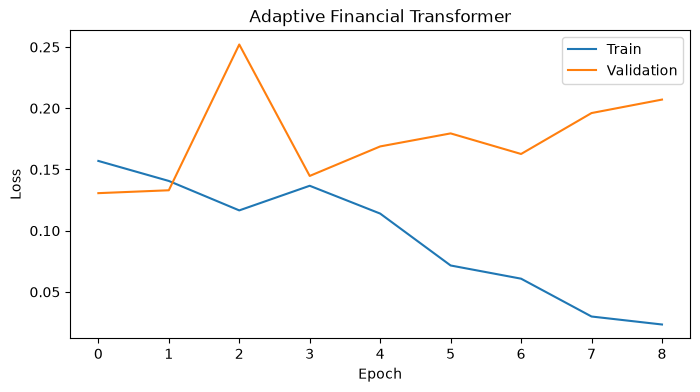

In [36]:
plt.figure(figsize=(8,4))

plt.plot(train_losses,label="Train")
plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Adaptive Financial Transformer")

plt.legend()

plt.show()

In [37]:
model.load_state_dict(
    torch.load(
        "models/adaptive_financial_transformer.pth",
        map_location=DEVICE
    )
)

model.eval()

AdaptiveFinancialTransformer(
  (embedding): Linear(in_features=95, out_features=128, bias=True)
  (position): PositionalEncoding()
  (dropout): Dropout(p=0.15, inplace=False)
  (layers): ModuleList(
    (0-1): 2 x EncoderBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attention): AdaptiveMultiHeadAttention(
        (q_proj): Linear(in_features=128, out_features=128, bias=True)
        (k_proj): Linear(in_features=128, out_features=128, bias=True)
        (v_proj): Linear(in_features=128, out_features=128, bias=True)
        (attention): AdaptiveFinancialAttention(
          (context): AdaptiveFinancialContext(
            (projections): ModuleDict(
              (price): Linear(in_features=7, out_features=16, bias=True)
              (returns): Linear(in_features=5, out_features=16, bias=True)
              (volatility): Linear(in_features=8, out_features=16, bias=True)
            

In [38]:
predictions=[]
targets=[]

model.eval()

with torch.no_grad():

    for X_batch,y_batch in val_loader:

        X_batch=X_batch.to(DEVICE)

        pred,_,_,_=model(X_batch)

        predictions.extend(pred.cpu().numpy())
        targets.extend(y_batch.cpu().numpy())

predictions=np.array(predictions)
targets=np.array(targets)

In [39]:
mae=mean_absolute_error(targets,predictions)

rmse=np.sqrt(
    mean_squared_error(targets,predictions)
)

r2=r2_score(
    targets,
    predictions
)

print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")

MAE  : 0.733650
RMSE : 0.753967
R²   : -575.519409


In [42]:
def calculate_trading_metrics(actual, predicted):

    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    actual_direction = np.sign(actual)
    predicted_direction = np.sign(predicted)

    directional_accuracy = np.mean(
        actual_direction == predicted_direction
    )

    hit_rate = directional_accuracy

    strategy_returns = predicted_direction * actual

    sharpe = (
        np.mean(strategy_returns)
        / (np.std(strategy_returns) + 1e-8)
    ) * np.sqrt(252)

    cumulative_returns = np.cumprod(1 + strategy_returns)

    running_max = np.maximum.accumulate(cumulative_returns)

    drawdown = (
        cumulative_returns - running_max
    ) / (running_max + 1e-8)

    max_drawdown = drawdown.min()

    return {
        "Directional Accuracy": directional_accuracy,
        "Hit Rate": hit_rate,
        "Sharpe": sharpe,
        "Strategy Return": strategy_returns.sum(),
        "Max Drawdown": max_drawdown
    }

In [43]:
metrics=calculate_trading_metrics(
    targets,
    predictions
)

metrics

{'Directional Accuracy': np.float64(0.5775862068965517),
 'Hit Rate': np.float64(0.5775862068965517),
 'Sharpe': np.float64(2.472790128294492),
 'Strategy Return': np.float32(1.7022052),
 'Max Drawdown': np.float32(-0.5685037)}

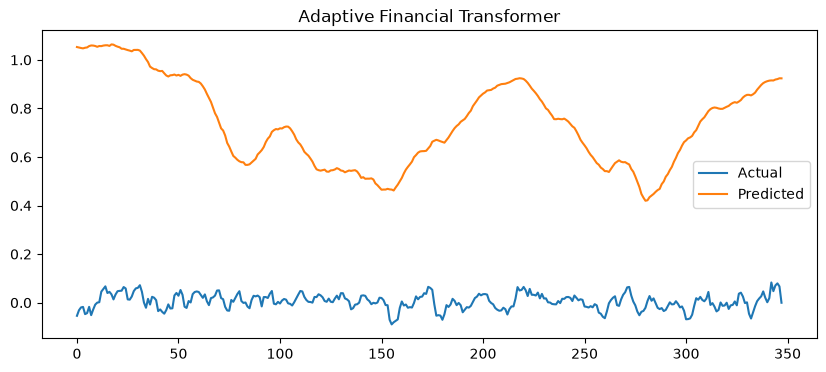

In [44]:
plt.figure(figsize=(10,4))

plt.plot(
    targets,
    label="Actual"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.legend()

plt.title("Adaptive Financial Transformer")

plt.show()

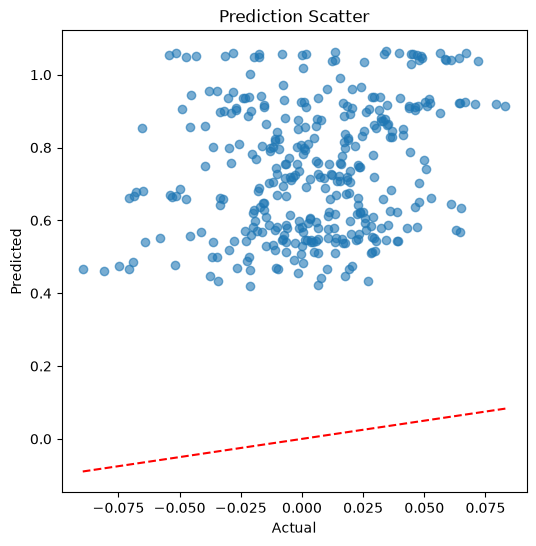

In [45]:
plt.figure(figsize=(6,6))

plt.scatter(
    targets,
    predictions,
    alpha=0.6
)

plt.plot(
    [targets.min(),targets.max()],
    [targets.min(),targets.max()],
    "r--"
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Prediction Scatter")

plt.show()

In [46]:
baseline=pd.read_csv("experiments/baseline_results.csv")

baseline.loc[len(baseline)]=[
    "De-biased Adaptive Transformer",
    mae,
    rmse,
    r2
]

baseline.to_csv("experiments/baseline_results.csv",index=False)

baseline.sort_values("MAE")

,Model,MAE,RMSE,R2
10,Adaptive Guided Transformer 2,0.024821,0.030637,0.039544
6,Custom Transformer,0.030962,0.043111,-0.045353
5,PyTorch Transformer,0.032234,0.043543,-0.066416
9,Feature Guided Transformer,0.032613,0.044231,-0.100367
1,Random Forest,0.033050,0.045135,-0.145847
4,XGBoost,0.034423,0.045011,-0.139553
3,GRU,0.034453,0.047614,-0.275127
2,LSTM,0.040036,0.052256,-0.535912
8,Adaptive Financial Transformer,0.131486,0.152851,-12.141038
0,Linear Regression,0.188742,0.248706,-33.790931


In [47]:
trading=pd.read_csv("experiments/trading_results.csv")

trading.loc[len(trading)]=[
    "De-biased Adaptive Transformer",
    metrics["Directional Accuracy"],
    metrics["Hit Rate"],
    metrics["Sharpe"],
    metrics["Strategy Return"],
    metrics["Max Drawdown"]
]

trading.to_csv("experiments/trading_results.csv",index=False)

trading.sort_values("Sharpe",ascending=False)

,Model,Directional Accuracy,Hit Rate,Sharpe,Strategy Return,Max Drawdown
10,Adaptive Financial Transformer 2,0.545977,0.545977,2.971212,2.028170,-0.413961
4,GRU,0.578797,0.578797,2.789059,8.535793,-0.703745
11,De-biased Adaptive Transformer,0.577586,0.577586,2.472790,1.702205,-0.568504
7,Price-Aware Transformer,0.564470,0.564470,1.752744,2.694752,-0.797920
8,Adaptive Financial Transformer,0.564470,0.564470,1.752744,2.694752,-0.797920
9,Feature Guided Transformer,0.521490,0.521490,0.539213,0.214492,-0.701339
1,Random Forest,0.515759,0.515759,0.334000,0.001970,-0.675468
6,Custom Transformer,0.521490,0.521490,0.177760,-0.139390,-0.601280
2,XGBoost,0.489971,0.489971,-0.132552,-0.350803,-0.741019
3,LSTM,0.478510,0.478510,-0.142696,-0.357364,-0.782726


In [48]:
experiment_log=pd.read_csv("experiments/experiment_log.csv")

experiment_log.loc[len(experiment_log)]={
    "Experiment":"De-biased Adaptive Transformer",
    "Model":"De-biased Adaptive Transformer",
    "Parameters":sum(p.numel() for p in model.parameters()),
    "Train Time (s)":round(train_time,2),
    "Epochs":best_epoch,
    "MAE":mae,
    "RMSE":rmse,
    "R2":r2,
    "Directional Accuracy":metrics["Directional Accuracy"],
    "Hit Rate":metrics["Hit Rate"],
    "Sharpe":metrics["Sharpe"],
    "Strategy Return":metrics["Strategy Return"],
    "Max Drawdown":metrics["Max Drawdown"],
    "Notes":"Dynamic gated adaptive financial attention"
}

experiment_log.to_csv("experiments/experiment_log.csv",index=False)

experiment_log.tail()

,Experiment,Model,Parameters,Train Time (s),Epochs,MAE,RMSE,R2,Directional Accuracy,Hit Rate,Sharpe,Strategy Return,Max Drawdown,Notes
17,Adaptive Financial Transformer,Adaptive Financial Transformer,297009.0,52.83,4.0,0.131486,0.152851,-12.141038,0.564470,0.564470,1.752744,2.694752,-0.797920,Dynamic gated adaptive financial attention
18,Adaptive Financial Transformer,Adaptive Financial Transformer,297009.0,52.83,4.0,0.131486,0.152851,-12.141038,0.564470,0.564470,1.752744,2.694752,-0.797920,Dynamic gated adaptive financial attention
19,Feature Guided Transformer,Feature Guided Transformer,279457.0,23.31,17.0,0.032613,0.044231,-0.100367,0.521490,0.521490,0.539213,0.214492,-0.701339,Dynamic gated adaptive financial attention
20,Adaptive Financial Transformer 2,Adaptive Financial Transformer 2,373143.0,35.11,7.0,0.024821,0.030637,0.039544,0.545977,0.545977,2.971212,2.028170,-0.413961,Dynamic gated adaptive financial attention
21,De-biased Adaptive Transformer,De-biased Adaptive Transformer,373143.0,12.69,1.0,0.733650,0.753967,-575.519409,0.577586,0.577586,2.472790,1.702205,-0.568504,Dynamic gated adaptive financial attention
